# Applied Deep Learning with TensorFlow – Part 1

This notebook follows the course material (Part 1/2).
It demonstrates tensor basics, regression, classification, and CNNs using TensorFlow.


# Applied Deep Learning with TensorFlow - Part 1

1.Tensor basics

2.Dtypes & casting

3.Indexing & reshaping

4.Broadcasting & basic operations

5.Matrix multiplication

6.Aggregations


In [2]:
import tensorflow as tf
import numpy as np
print("TF:", tf.__version__)

# Scalars, vectors, matrices, tensors
scalar = tf.constant(7)                 # rank-0
vector = tf.constant([10, 20, 30])       # rank-1
matrix = tf.constant([[1., 2.], [3., 4.]])  # rank-2
tensor = tf.constant([[[1],[2]], [[3],[4]]]) # rank-3

print("Shapes of tensors:")
print("Scalar:", scalar.shape)
print("Vector:", vector.shape)
print("Matrix:", matrix.shape)
print("Tensor:", tensor.shape)


TF: 2.20.0
Shapes of tensors:
Scalar: ()
Vector: (3,)
Matrix: (2, 2)
Tensor: (2, 2, 1)


### Notes
- `.shape` shows the dimensions of the tensor.
- Scalars have no dimensions.
- Vectors have 1 dimension, matrices 2 dimensions, tensors can have more.
- Shape mismatches are a common source of errors in deep learning.


### Tensor Data Types (dtypes) and Casting
- Each tensor has a data type (`dtype`) that affects memory usage and precision.
- TensorFlow defaults:
    - `float32` for decimals
    - `int32` for integers
- You can **cast** a tensor to a different dtype when needed.


In [3]:
# Dtypes and casting
x = tf.constant([1.7, 7.4])  # default float32
y = tf.constant([7, 10])     # default int32

# Cast to different types
x16 = tf.cast(x, tf.float16)  # reduce precision float
x = tf.cast(x.tf.float32)
y32 = tf.cast(y, tf.float32)  # int -> float

print("Original x:", x, "dtype:", x.dtype)
print("x16:", x16, "dtype:", x16.dtype)
print("Original y:", y, "dtype:", y.dtype)
print("y32:", y32, "dtype:", y32.dtype)


Original x: tf.Tensor([1.7 7.4], shape=(2,), dtype=float32) dtype: <dtype: 'float32'>
x16: tf.Tensor([1.7 7.4], shape=(2,), dtype=float16) dtype: <dtype: 'float16'>
Original y: tf.Tensor([ 7 10], shape=(2,), dtype=int32) dtype: <dtype: 'int32'>
y32: tf.Tensor([ 7. 10.], shape=(2,), dtype=float32) dtype: <dtype: 'float32'>


### Notes
- `.dtype` shows the type of the tensor.
- Casting can save memory or match other tensors for operations.
- Always check dtypes before doing math to avoid errors.


### Indexing and Reshaping
- You can **slice tensors** to access parts of them.
- Use `tf.expand_dims` to add an axis (like channels in images).
- Use `tf.squeeze` to remove axes of size 1.


In [4]:
rank2 = tf.constant([[10, 7], [3, 4]])

# Indexing: get last column
last_col = rank2[:, -1] # column slice

# Expand dims
expanded = tf.expand_dims(rank2, -1)  # add channel-like axis

# Squeeze
squeezed = tf.squeeze(expanded, axis=-1)

print("Original matrix:\n", rank2.numpy())
print("Last column:\n", last_col.numpy())
print("Expanded shape:", expanded.shape)
print("Squeezed shape:", squeezed.shape)


Original matrix:
 [[10  7]
 [ 3  4]]
Last column:
 [7 4]
Expanded shape: (2, 2, 1)
Squeezed shape: (2, 2)


### Notes
- `:` selects all rows/columns, `-1` is the last index.
- `expand_dims` adds a dimension (useful for CNN inputs).
- `squeeze` removes unnecessary dimensions.
- Correct tensor shapes are crucial to avoid shape mismatch errors.


### Broadcasting and Basic Operations
- TensorFlow supports **element-wise operations** like addition, multiplication, etc.
- **Broadcasting** allows operations between tensors of different shapes when compatible.
- Example: Adding a scalar to a matrix adds it to every element.


In [5]:
A = tf.constant([[10., 7.], [3., 4.]])

# Broadcasting examples
print("Matrix A:\n", A.numpy())
print("A + 10:\n", (A + 10).numpy())  # adds 10 to every element
print("A * 2:\n", (A * 2).numpy())    # multiplies every element by 2


Matrix A:
 [[10.  7.]
 [ 3.  4.]]
A + 10:
 [[20. 17.]
 [13. 14.]]
A * 2:
 [[20. 14.]
 [ 6.  8.]]


### Notes
- Operations are applied **element-wise** by default.
- Broadcasting saves you from manually repeating data.
- Always check shapes; incompatible shapes will raise errors.


### Matrix Multiplication
- Dense layers in neural networks perform **matrix multiplication**:
    output = inputs * weights + bias
- Rule: Inner dimensions must match: (m x n) @ (n x p) → result (m x p)


In [6]:
# Matrix multiplication
X = tf.constant([[1, 2], [3, 4], [5, 6]], dtype=tf.float32)  # shape (3,2)
Y = tf.constant([[7, 8], [9, 10], [11, 12]], dtype=tf.float32) # shape (3,2)

# Transpose Y to match inner dimension
XtY = tf.matmul(X, tf.transpose(Y))  # (3,2) @ (2,3) -> (3,3)

print("X shape:", X.shape)
print("Y shape:", Y.shape)
print("X @ Y.T shape:", XtY.shape)
print("Result:\n", XtY.numpy())


X shape: (3, 2)
Y shape: (3, 2)
X @ Y.T shape: (3, 3)
Result:
 [[ 23.  29.  35.]
 [ 53.  67.  81.]
 [ 83. 105. 127.]]


### Notes
- `tf.matmul` performs matrix multiplication.
- Use `.T` to transpose matrices when needed.
- Matrix multiplication is **central to neural networks**.


### Aggregations
- TensorFlow supports aggregation operations:
    - `reduce_min`, `reduce_max`, `reduce_mean`, `reduce_sum`
- Useful for computing statistics over a tensor.


In [7]:
E = tf.constant(np.random.randint(0, 100, size=10))
print("E:", E.numpy())
print("min:", tf.reduce_min(E).numpy())
print("max:", tf.reduce_max(E).numpy())
print("mean:", tf.reduce_mean(tf.cast(E, tf.float32)).numpy())
print("sum:", tf.reduce_sum(E).numpy())


E: [83 55 33 23 93 56  8 96 99 96]
min: 8
max: 99
mean: 64.2
sum: 642



 Regression (Neural Network predicting a number) 
## Neural Network Regression
- Regression predicts **continuous numerical values**.
- Example: learning the rule `y = x + 10`.
- Steps:
  1. Create the model architecture
  2. Compile the model with loss function and optimizer
  3. Fit the model on training data
  4. Evaluate on test data
- Loss function: Mean Absolute Error (MAE)


In [8]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# Synthetic linear data
X = np.arange(-20, 21, 2, dtype=np.float32)  # [-20, -18, ..., 20]
y = X + 10

# Simple train/test split
X_train, y_train = X[:20], y[:20]
X_test, y_test = X[20:], y[20:]

print("X_train:", X_train)
print("X_test:", X_test)


X_train: [-20. -18. -16. -14. -12. -10.  -8.  -6.  -4.  -2.   0.   2.   4.   6.
   8.  10.  12.  14.  16.  18.]
X_test: [20.]


### Notes
- Training set: first 20 numbers
- Test set: remaining numbers
- Model will **learn the linear relationship** and generalize to unseen inputs.


In [9]:
# 1) CREATE
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(1,)),  # input layer
    tf.keras.layers.Dense(1)            # linear output for regression
])

# 2) COMPILE
model.compile(
    loss="mae",  # mean absolute error
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
    metrics=["mae"]
)


### Notes
- Input shape = 1 (just x value)
- Output = 1 (y value)
- SGD optimizer updates weights to minimize MAE


In [10]:
# 3) FIT
history = model.fit(X_train, y_train, epochs=800, verbose=0)

# Evaluate
loss, mae = model.evaluate(X_test, y_test, verbose=0)
print("Test MAE:", mae)


Test MAE: 5.083251953125


### Notes
- Model trains over 200 epochs.
- Evaluate using **test data**, not training data, to check generalization.
- MAE shows the average prediction error.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


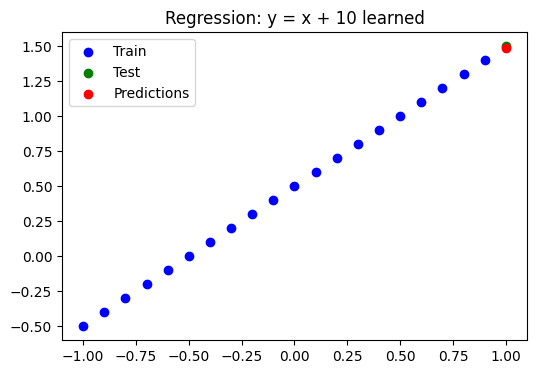

In [15]:
# Predict
y_pred = model.predict(X_test).squeeze()

# Plot results
plt.figure(figsize=(6,4))
plt.scatter(X_train, y_train, c='b', label='Train')
plt.scatter(X_test, y_test, c='g', label='Test')
plt.scatter(X_test, y_pred, c='r', label='Predictions')
plt.legend()
plt.title("Regression: y = x + 10 learned")
plt.show()


### Notes
- Blue points: training data
- Green points: test data
- Red points: predicted values
- Visualization helps **see if model learned the correct relationship**.


Binary Classification: Non-linear Data (Circles)
- Classification predicts **categories**, not numbers.
- Binary classification: output is 0 or 1.
- Non-linear data example: points arranged in concentric circles.
- Use **non-linear activations** (e.g., ReLU) + **sigmoid output** + **binary cross-entropy loss**.


Test MAE: 0.0074388980865478516
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


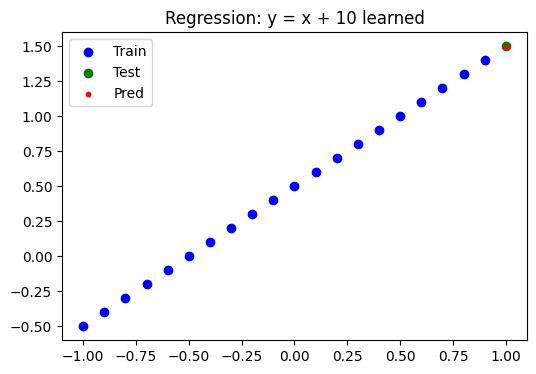

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

X = np.arange(-20, 21, 2)

y = X + 10

# Normalize
X = X / 20.0
y = y / 20.0

X_train, y_train = X[:20], y[:20]
X_test, y_test = X[20:], y[20:]

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(1,)),
    tf.keras.layers.Dense(1)
])

model.compile(
    loss="mae",
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.05),
    metrics=["mae"]
)

model.fit(
    X_train,y_train,epochs=500,verbose=0
)
loss, mae = model.evaluate(X_test, y_test, verbose=0)
print("Test MAE:", mae)
y_pred = model.predict(X_test).squeeze()
plt.figure(figsize=(6,4))
plt.scatter(X_train, y_train, c='b', label='Train')
plt.scatter(X_test, y_test, c='g', label='Test')
plt.scatter(X_test, y_pred, c='r', label='Pred',s=10)
plt.legend()
plt.title("Regression: y = x + 10 learned")
plt.show()

In [22]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt


# 1) DATA 

X = np.arange(-100, 101, 5, dtype=np.float32)  
y = X + 10

# Train/test split
split = int(len(X) * 0.7)
X_train, y_train = X[:split], y[:split]
X_test, y_test = X[split:], y[split:]



In [23]:
len(X)

41

MSE - it gives stronger gardients when predistions are off and it also hepls the model to ajust the w(weight) and b(bias)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


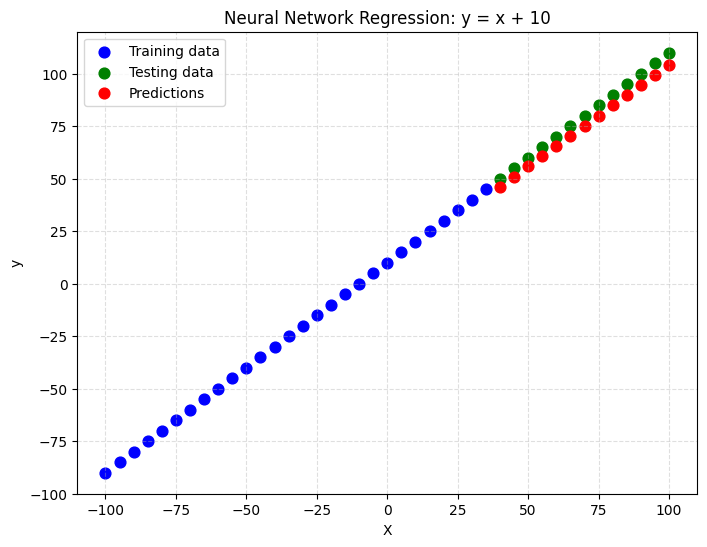

In [26]:
# 2) MODEL

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(1,)),
    tf.keras.layers.Dense(1)
])

model.compile(
    loss="mse",
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.1),
    metrics=["mae"]
)


# 3) FIT
model.fit(X_train, y_train, epochs=200, verbose=0)



# 4) PREDICT

y_pred = model.predict(X_test).squeeze()


# 5) PLOT 
plt.figure(figsize=(8,6))

plt.scatter(X_train, y_train, color="blue", label="Training data", s=60)
plt.scatter(X_test, y_test, color="green", label="Testing data", s=60)
plt.scatter(X_test, y_pred, color="red", label="Predictions", s=60)

plt.xlabel("X")
plt.ylabel("y")
plt.title("Neural Network Regression: y = x + 10")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()

plt.show()


In [25]:
#evaluate was not here
model.evaluate(X_test,y_test,verbose=0)

[0.09911388903856277, 0.312479168176651]

In [54]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split

# Create non-linear separable data
X, y = make_circles(n_samples=1000, 
                    noise=0.03, 
                    random_state=42)

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Visualize data

#plt.figure(figsize=(5,5))
#plt.scatter(X[:,0], X[:,1], c=y, cmap=plt.cm.RdYlBu, edgecolor='k', alpha=0.6)
#plt.title("Non-linear data (circles)")
#plt.show()


### Notes
- `make_circles` generates 2 classes (0: inner circle, 1: outer circle).
- Data is **non-linearly separable**; straight lines cannot separate classes.
- Visualizing data helps understand the problem before training.


In [53]:
# 1) CREATE model
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(2,)),  # 2 features (x, y)
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")  # binary output
])

# 2) COMPILE model
model.compile(
    loss="binary_crossentropy",
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    metrics=["accuracy"]
)


### Notes
- Use **ReLU** for hidden layers to capture non-linear relationships.
- Output layer uses **sigmoid** for binary probabilities.
- Binary cross-entropy measures the difference between predicted probabilities and true labels.


In [62]:
# 3) FIT model
history = model.fit(X_train, y_train, epochs=25, verbose=0)

# Evaluate model
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy: {acc:.3f}")


Test accuracy: 0.995


### Notes
- Training for 25 epochs is enough for this small dataset.
- Accuracy shows how well the model generalizes to unseen data.


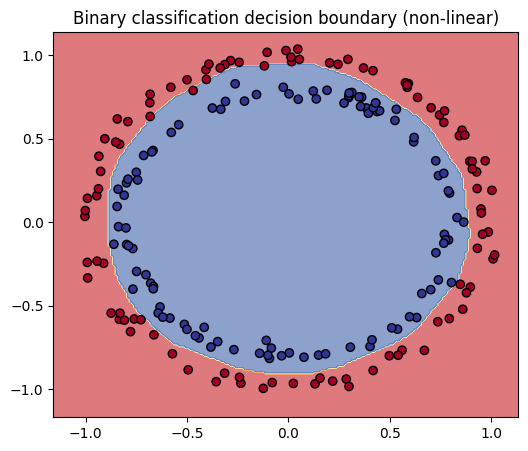

In [24]:
# Create a grid for plotting decision boundary
xx, yy = np.meshgrid(
    np.linspace(X[:,0].min()-0.1, X[:,0].max()+0.1, 200),
    np.linspace(X[:,1].min()-0.1, X[:,1].max()+0.1, 200)
)
grid = np.c_[xx.ravel(), yy.ravel()]

# Predict probabilities on the grid
probs = model.predict(grid, verbose=0).reshape(xx.shape)

# Plot decision boundary
plt.figure(figsize=(6,5))
plt.contourf(xx, yy, (probs>0.5).astype(int), cmap=plt.cm.RdYlBu, alpha=0.6)
plt.scatter(X_test[:,0], X_test[:,1], c=y_test, cmap=plt.cm.RdYlBu, edgecolor='k')
plt.title("Binary classification decision boundary (non-linear)")
plt.show()


### Notes
- Red/Blue regions: model prediction for each class.
- Scatter points: actual test data.
- Non-linear activations allow the model to create **curved decision boundaries**.
- This is why simple linear models fail on circle-type data.


## Multiclass Classification: Fashion-MNIST
- Goal: classify images into **10 classes** (0–9).
- Use **softmax output** + **categorical/sparse cross-entropy loss**.
- Images are **28x28 grayscale pixels**.
- Normalize pixel values to [0, 1] for faster, stable training.
- Typical network: Flatten → Dense (ReLU) → Dense (Softmax).


In [3]:
import tensorflow as tf
import matplotlib.pyplot as plt

# Load Fashion-MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

# Normalize images to [0,1]
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Check shapes
''' print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_test shape:", x_test.shape)
print("y_test shape:", y_test.shape) '''


' print("x_train shape:", x_train.shape)\nprint("y_train shape:", y_train.shape)\nprint("x_test shape:", x_test.shape)\nprint("y_test shape:", y_test.shape) '

### Notes
- 60,000 training images, 10,000 test images.
- Each image is 28x28 pixels (grayscale).
- Labels are integers (0–9), not one-hot.
- Normalization speeds up training and stabilizes gradients.


In [4]:
# 1) CREATE model
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28,28)),  # input images
    tf.keras.layers.Flatten(),             # flatten 2D image into 1D vector
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")  # 10 classes
])

# 2) COMPILE model
model.compile(
    loss="sparse_categorical_crossentropy",  # use sparse version because labels are integers
    optimizer="adam",
    metrics=["accuracy"]
)


### Notes
- Flatten converts 28x28 image to 784-element vector.
- Hidden Dense layer with **ReLU** learns features.
- Output layer with **Softmax** gives probabilities for each class.
- Loss: sparse categorical cross-entropy (integer labels).


In [5]:
# 3) FIT model
history = model.fit(
    x_train, y_train,
    epochs=10,
    validation_split=0.1,
    verbose=1
)

# Evaluate
loss, acc = model.evaluate(x_test, y_test, verbose=0)
print("Test accuracy:", acc)


Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 828us/step - accuracy: 0.8229 - loss: 0.5074 - val_accuracy: 0.8593 - val_loss: 0.4007
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 752us/step - accuracy: 0.8629 - loss: 0.3838 - val_accuracy: 0.8623 - val_loss: 0.3824
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 784us/step - accuracy: 0.8759 - loss: 0.3394 - val_accuracy: 0.8733 - val_loss: 0.3550
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 743us/step - accuracy: 0.8839 - loss: 0.3167 - val_accuracy: 0.8718 - val_loss: 0.3532
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 773us/step - accuracy: 0.8921 - loss: 0.2964 - val_accuracy: 0.8788 - val_loss: 0.3291
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 783us/step - accuracy: 0.8963 - loss: 0.2807 - val_accuracy: 0.8822 - val_loss: 0.3332
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 776us/step - accuracy: 0.9000 - loss: 0.2686 - val_accuracy: 0.8622 - val_loss: 0.3717
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 762us/step - accuracy: 0.9038 -

### Notes
- Validation split = 10% of training data (used for monitoring).
- Training for 10 epochs should give **~88-90% accuracy**.
- Test accuracy shows model generalization on unseen images.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


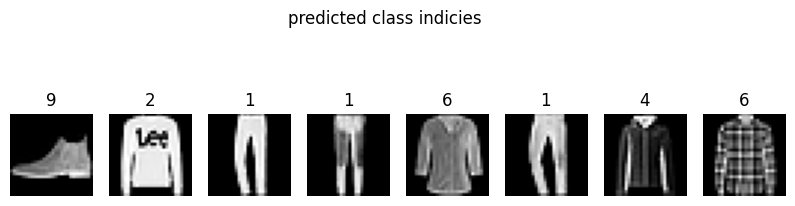

In [8]:
# Predict first 8 images
preds = model.predict(x_test[:8]).argmax(axis=1)


plt.figure(figsize=(10,3))
for i in range(8):
    plt.subplot(1,8,i+1)
    plt.imshow(x_test[i],cmap="gray")
    plt.title(int(preds[i]))
    plt.axis('off')
plt.suptitle("predicted class indicies")
plt.show()



### Notes
- Each subplot shows the **predicted class index** of the corresponding image.
- Softmax outputs probabilities; `argmax` selects the class with highest probability.
- This visualization helps **verify model predictions visually**.


# Convolutional Neural Networks (CNNs)
- Goal: classify images using **spatial patterns** instead of just flat pixel vectors.
- CNNs preserve spatial relationships in images.
- Layers:
  - Convolution (`Conv2D`) → extracts local features like edges, corners
  - Activation (ReLU) → adds non-linearity
  - Pooling (`MaxPool2D`) → reduces resolution while keeping important info
  - Fully connected (`Dense`) → makes final prediction
- We'll use a small **binary subset of Fashion-MNIST** (Sneaker vs Ankle boot).


In [38]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# Load Fashion-MNIST
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

# Keep only classes 7 (Sneaker) and 9 (Ankle boot) for binary classification
train_mask = np.isin(y_train, [7, 9])
test_mask = np.isin(y_test, [7, 9])

x_train = x_train[train_mask][..., None] / 255.0  # Add channel dimension
y_train = (y_train[train_mask] == 9).astype(np.float32)  # 1 if class 9, else 0

x_test = x_test[test_mask][..., None] / 255.0
y_test = (y_test[test_mask] == 9).astype(np.float32)

print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)


x_train shape: (12000, 28, 28, 1)
y_train shape: (12000,)


### Notes
- We add a **channel dimension** `[28,28] → [28,28,1]` for CNN input.
- Labels converted to **0 or 1** for binary classification.
- Pixel values normalized to [0,1].


In [39]:
# 1) CREATE small CNN
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28,28,1)),
    tf.keras.layers.Conv2D(16, 3, activation="relu"),
    tf.keras.layers.MaxPool2D(),
    tf.keras.layers.Conv2D(32, 3, activation="relu"),
    tf.keras.layers.MaxPool2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")  # Binary output
])

# 2) COMPILE
model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)


### Notes
- Two Conv2D + MaxPool layers extract features.
- Flatten layer converts 2D feature maps into a vector.
- Dense layer with ReLU learns patterns.
- Output layer uses Sigmoid for **binary probability**.


In [ ]:
# 3) FIT
history = model.fit(
    x_train, y_train,
    epochs=5,
    validation_split=0.1,
    verbose=1
)

# Evaluate
loss, acc = model.evaluate(x_test, y_test, verbose=0)
print("Test accuracy:", acc)


### Notes
- Training for 5 epochs should give **~90%+ accuracy** on binary subset.
- Validation split = 10% of training data.
- CNNs outperform flat Dense networks on images because they **learn spatial features**.


## Transfer Learning
- Instead of training a CNN from scratch, reuse a pretrained model.
- Two strategies:
  1. **Feature extraction**: Freeze pretrained layers, train only a new head.
  2. **Fine-tuning**: Retrain some layers for your data.
- Advantages:
  - Faster training
  - Works with smaller datasets
  - Leverages learned visual features (edges, textures, shapes)
- We'll use a small subset of **CIFAR-10** classes (0,1,2).


In [9]:
from tensorflow.keras import layers, models

# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Keep only classes 0,1,2
mask_train = (y_train < 3).flatten()
mask_test = (y_test < 3).flatten()

x_train = x_train[mask_train].astype("float32") / 255.0
y_train = y_train[mask_train].flatten()

x_test = x_test[mask_test].astype("float32") / 255.0
y_test = y_test[mask_test].flatten()

print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 115s 1us/step
x_train shape: (15000, 32, 32, 3)
y_train shape: (15000,)


### Notes
- Images are 32×32×3 (RGB).
- Labels are integers 0,1,2.
- Pixel values normalized to [0,1].


In [10]:
# Small CNN (base for transfer learning demo)
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation="relu", padding="same", input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, (3,3), activation="relu", padding="same"),
    layers.MaxPooling2D(),
    layers.Conv2D(128, (3,3), activation="relu", padding="same"),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(3, activation="softmax")  # 3 classes
])

# Compile
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### Notes
- Conv2D + MaxPool layers extract features.
- Dense layers classify into 3 categories.
- Output layer uses **Softmax** for multiclass classification.
- Loss function = sparse_categorical_crossentropy because labels are integers.


In [11]:
# Train
history = model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

# Evaluate
loss, acc = model.evaluate(x_test, y_test, verbose=0)
print("Test accuracy (small CNN):", acc)


Epoch 1/5
211/211 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.7255 - loss: 0.6402 - val_accuracy: 0.8453 - val_loss: 0.4168
Epoch 2/5
211/211 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.8483 - loss: 0.3843 - val_accuracy: 0.8893 - val_loss: 0.3108
Epoch 3/5
211/211 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.8841 - loss: 0.3028 - val_accuracy: 0.8973 - val_loss: 0.2837
Epoch 4/5
211/211 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.9010 - loss: 0.2603 - val_accuracy: 0.9107 - val_loss: 0.2555
Epoch 5/5
211/211 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.9167 - loss: 0.2216 - val_accuracy: 0.9040 - val_loss: 0.2601
Test accuracy (small CNN): 0.8989999890327454


### Notes
- Feature extraction allows using **pretrained knowledge** if needed.
- Small CNN trained for only 5 epochs should achieve **reasonable accuracy** (~70–80% on this subset).
- Key idea: Transfer learning = knowledge reuse → saves time + data.
